# Applied Machine Learning for a FinTech Startup
## Credit Card Fraud Detection




In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [23]:
# Load dataset
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
# Quick data checks
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nClass distribution:")
print(df["Class"].value_counts())
print("\nFraud rate:", df["Class"].mean())


Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.001727485630620034


## EDA (Exploratory Data Analysis)

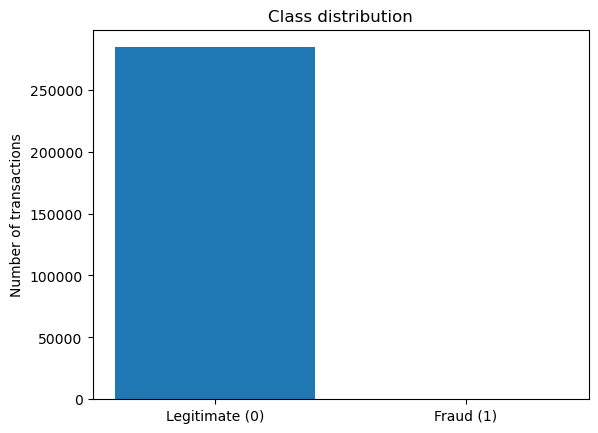

In [5]:
# Class distribution plot
counts = df["Class"].value_counts().sort_index()
plt.figure()
plt.bar(["Legitimate (0)", "Fraud (1)"], counts.values)
plt.title("Class distribution")
plt.ylabel("Number of transactions")
plt.show()


In [6]:
# Amount summary by class
summary = df.groupby("Class")["Amount"].describe()
summary


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Feature engineering

In [7]:
# Feature engineering: hour_of_day, is_night, log_amount
df_fe = df.copy()
df_fe["hour_of_day"] = ((df_fe["Time"] / 3600) % 24).astype(float)
df_fe["is_night"] = (df_fe["hour_of_day"].between(0, 6)).astype(int)
df_fe["log_amount"] = np.log1p(df_fe["Amount"])

# Split X/y
X = df_fe.drop(columns=["Class"])
y = df_fe["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())


Train shape: (227845, 33) Test shape: (56962, 33)
Train fraud rate: 0.001729245759178389 Test fraud rate: 0.0017204452090867595


## Models

In [8]:
# Baseline model: Logistic Regression (with scaling)
lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Primary model: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE
)

# Train
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Training completed")


Training completed


## Evaluation

Logistic Regression (baseline)
              precision    recall  f1-score   support

           0     0.9999    0.9742    0.9869     56864
           1     0.0579    0.9184    0.1089        98

    accuracy                         0.9741     56962
   macro avg     0.5289    0.9463    0.5479     56962
weighted avg     0.9982    0.9741    0.9854     56962



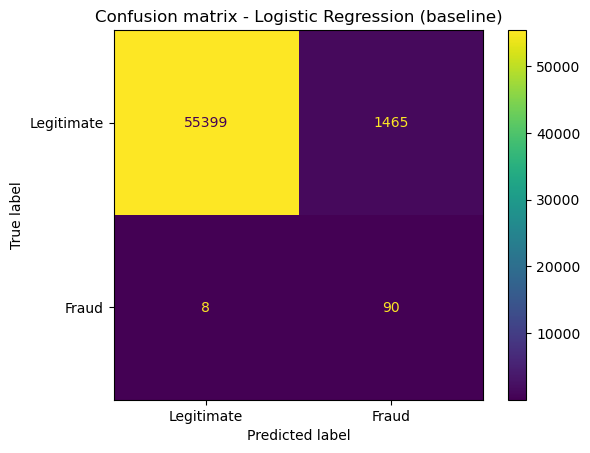

ROC-AUC: 0.9717
PR-AUC (Average Precision): 0.7231
Random Forest (primary)
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962



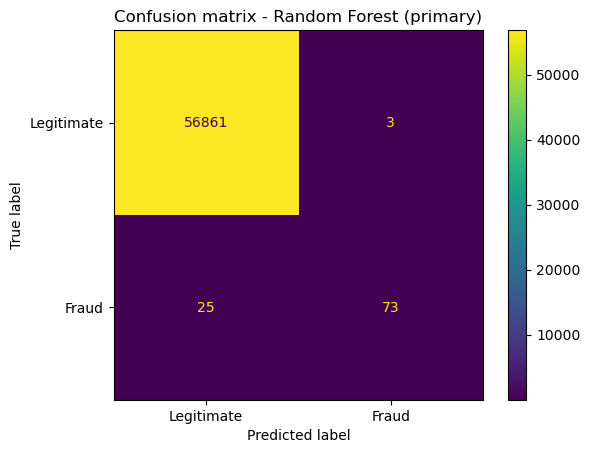

ROC-AUC: 0.9568
PR-AUC (Average Precision): 0.8710


In [25]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print("="*80)
    print(name)
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
    disp.plot()
    plt.title(f"Confusion matrix - {name}")
    plt.show()

    if y_prob is not None:
        roc = roc_auc_score(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        print(f"ROC-AUC: {roc:.4f}")
        print(f"PR-AUC (Average Precision): {ap:.4f}")
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model("Logistic Regression (baseline)", lr_model, X_test, y_test)
rf_pred, rf_prob = evaluate_model("Random Forest (primary)", rf_model, X_test, y_test)


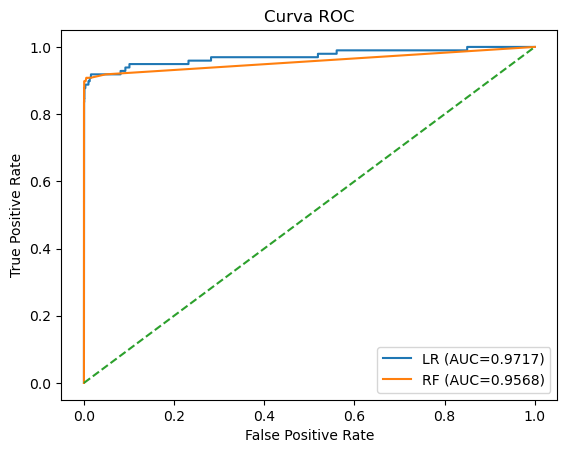

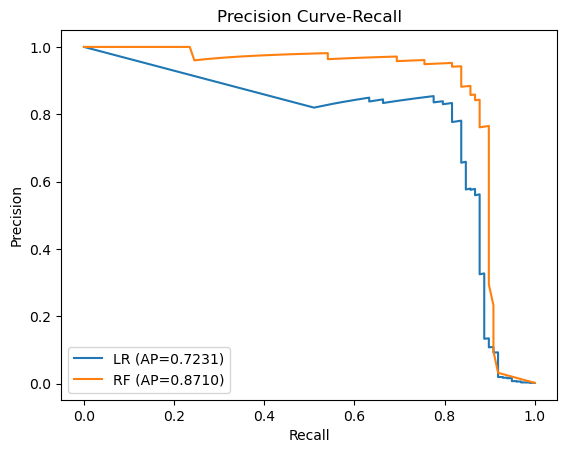

In [26]:
# ROC and Precision-Recall curves
plt.figure()
for name, prob in [("LR", lr_prob), ("RF", rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.4f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

plt.figure()
for name, prob in [("LR", lr_prob), ("RF", rf_prob)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, prob):.4f})")
plt.title("Precision Curve-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


## Model Selection, Comparison, and Evaluation Metrics

### Comparison Model
Logistic Regression was selected as the comparison (baseline) model. It is a widely used and well 
understood
linear classifier that provides a strong baseline for binary classification problems. Due to its simplicity
and interpretability, it allows for an initial assessment of model performance before applying more complex models.

### Primary Model Justification
Random Forest was chosen as the primary model because the fraud detection problem involves complex,
non-linear relationships between features. The dataset contains anonymized PCA components (V1–V28),
making it difficult for linear models to capture interactions effectively. Random Forest is well suited
to this scenario as it can model non-linear patterns, is robust to noise, and handles high-dimensional data
without strong assumptions about feature distributions.

In addition, Random Forest is relatively robust to class imbalance and provides feature importance measures,
which support model interpretability when combined with SHAP.

### Evaluation Metrics
Given the extreme class imbalance in the dataset, accuracy alone is not an appropriate evaluation metric.
Instead, the following metrics were selected:

- **Recall (Fraud Class):** Measures the proportion of actual fraudulent transactions correctly identified.
  High recall is critical in fraud detection, as failing to detect fraud can result in significant financial losses.

- **Precision (Fraud Class):** Measures the proportion of predicted fraud cases that are truly fraudulent.
  This metric reflects the cost of false positives.

- **F1-score:** Provides a balance between precision and recall.

- **ROC-AUC:** Evaluates the model’s ability to discriminate between classes across different thresholds.

- **Precision–Recall AUC (PR-AUC):** Particularly informative for highly imbalanced datasets and therefore
  a key metric in this problem.

These metrics together provide a comprehensive evaluation of model performance under real-world fraud detection constraints.


## SHAP Explainability (Random Forest)



In [27]:
import typing

try:
    import coverage
    for name, val in {
        "Tracer": object,
        "TShouldTraceFn": typing.Callable,
        "TShouldStartContextFn": typing.Callable
    }.items():
        if not hasattr(coverage.types, name):
            setattr(coverage.types, name, val)
except ModuleNotFoundError:
    # coverage is not installed; nothing to patch
    pass



In [28]:
# Import SHAP safely
try:
    import shap
    shap.initjs()
except Exception as e:
    print("SHAP could not be imported:", e)


X_shap: (2000, 33) SV class1: (2000, 33)


C:\Users\nathi\AppData\Local\Temp\ipykernel_21100\2285333358.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_class1, X_shap, show=False)


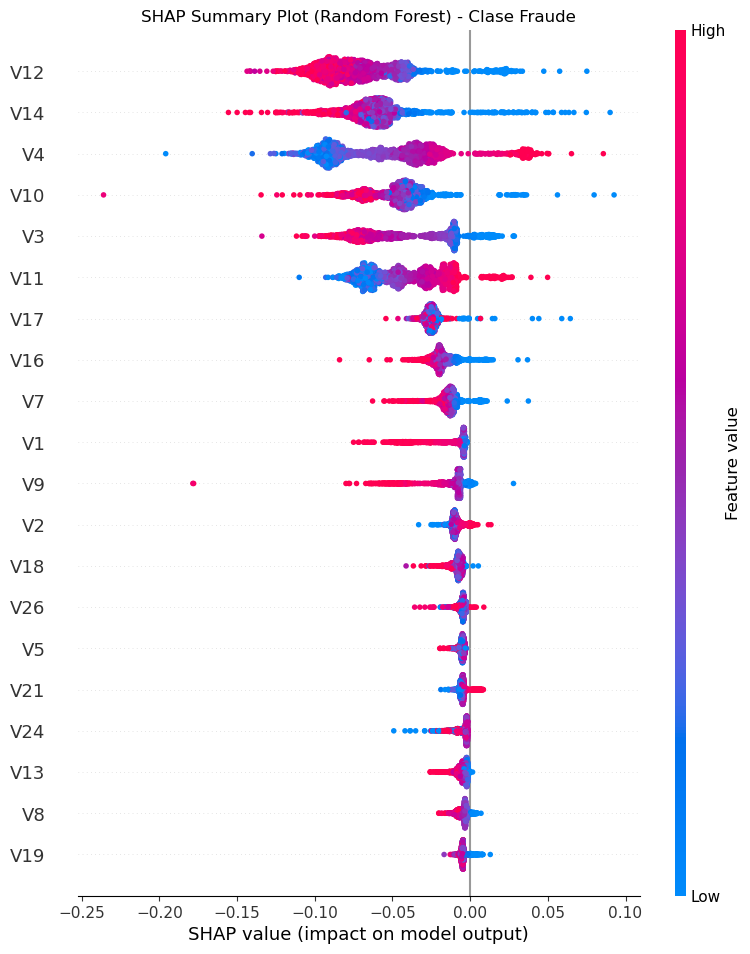

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(rf_model)
sv = explainer.shap_values(X_shap)

#  Normalize SHAP values ​​to (n_samples, n_features) for class 1.
if isinstance(sv, list):
    
    sv_class1 = sv[1]
else:
    sv_arr = np.array(sv)
    if sv_arr.ndim == 3:
        
        if sv_arr.shape[2] == 2:
            sv_class1 = sv_arr[:, :, 1]
        elif sv_arr.shape[0] == 2:
            sv_class1 = sv_arr[1, :, :]
        else:
            raise ValueError(f"Unexpected SHAP shape: {sv_arr.shape}")
    elif sv_arr.ndim == 2:
        sv_class1 = sv_arr
    else:
        raise ValueError(f"Unexpected SHAP ndim: {sv_arr.ndim}, shape: {sv_arr.shape}")


if sv_class1.shape[1] == X_shap.shape[1] + 1:
    sv_class1 = sv_class1[:, :-1]


print("X_shap:", X_shap.shape, "SV class1:", sv_class1.shape)

shap.summary_plot(sv_class1, X_shap, show=False)
plt.title("SHAP Summary Plot (Random Forest) - Clase Fraude")
plt.show()


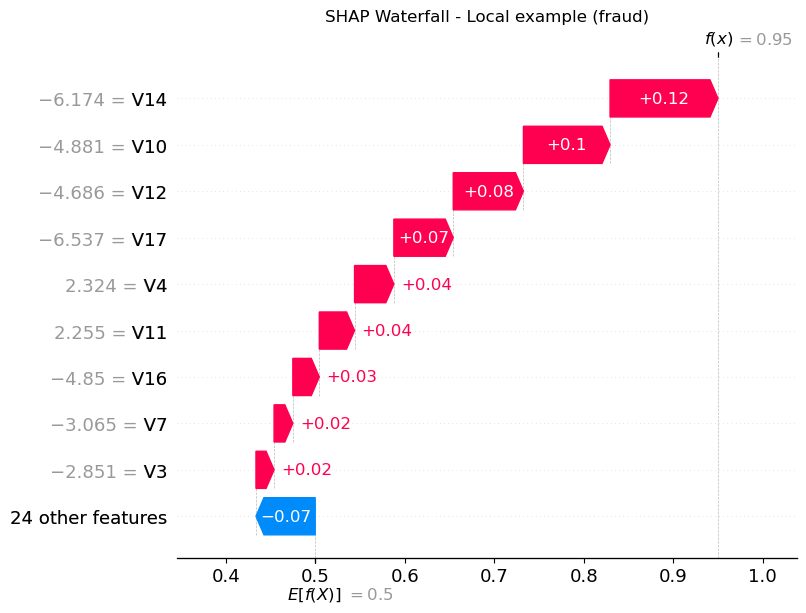

Example index: 77348 | Predicted fraud probability: 0.9500


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# Local explanation: I pick one fraudulent case from test set (if available)
fraud_idx = X_test[y_test == 1].index

if len(fraud_idx) == 0:
    print("There are no examples of fraud in the test set (rare with stratified split testing).")
else:
    idx = fraud_idx[0]
    x_one = X_test.loc[[idx]]

    # Get shap values for a single row
    sv_one = explainer.shap_values(x_one)

    # ---- Normalize to (1, n_features) for class 1 ----
    if isinstance(sv_one, list):
        shap_one = sv_one[1]               # shape (1, n_features) (usually)
        base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        sv_arr = np.array(sv_one)
        if sv_arr.ndim == 3:
            # (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
            if sv_arr.shape[2] == 2:
                shap_one = sv_arr[:, :, 1]
            elif sv_arr.shape[0] == 2:
                shap_one = sv_arr[1, :, :]
            else:
                raise ValueError(f"Unexpected SHAP shape: {sv_arr.shape}")
        elif sv_arr.ndim == 2:
            shap_one = sv_arr
        else:
            raise ValueError(f"Unexpected SHAP ndim: {sv_arr.ndim}, shape: {sv_arr.shape}")

        # expected_value handling
        if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) >= 2:
            base_val = explainer.expected_value[1]
        else:
            base_val = explainer.expected_value

    # If a bias column exists, drop it
    if shap_one.shape[1] == x_one.shape[1] + 1:
        shap_one = shap_one[:, :-1]

    # Build Explanation object and plot
    exp = shap.Explanation(
        values=shap_one[0],
        base_values=base_val,
        data=x_one.iloc[0].values,
        feature_names=x_one.columns
    )

    shap.waterfall_plot(exp, show=False)
    plt.title("SHAP Waterfall - Local example (fraud)")
    plt.show()

    # Optional: print model probability for that transaction
    proba = rf_model.predict_proba(x_one)[0, 1]
    print(f"Example index: {idx} | Predicted fraud probability: {proba:.4f}")



### Local SHAP Explanation – Fraud Case

Figure X shows a SHAP waterfall plot for a fraudulent transaction from the test set.
The Random Forest model assigned a fraud probability of **0.95**, indicating high confidence.
Features V14, V10, V12, and V17 contributed most strongly to increasing the prediction toward the fraud class.
Although several other features reduced the predicted risk, their combined effect was insufficient to offset
the strong fraud-indicative signals.
This example demonstrates how SHAP provides transparent, instance-level explanations for model decisions.



## Explainability (XAI)

To explain the decisions made by the Random Forest model, SHAP (SHapley Additive exPlanations) was used.
SHAP provides both global and local interpretability by quantifying the contribution of each feature
to the model’s predictions.

### Model Transparency
The SHAP summary plot offers a global view of feature importance, showing which variables most strongly
influence the model’s predictions across the dataset. This transparency helps reveal how the model
leverages both anonymized PCA components (V-features) and engineered features to identify fraudulent patterns,
making the model behavior more understandable despite its complexity.

### Trust
By providing local explanations through SHAP waterfall plots, individual predictions can be examined
in detail. For example, a fraudulent transaction was assigned a fraud probability of 0.95, with features
such as V14, V10, V12, and V17 contributing most strongly to the prediction.
This instance-level explanation increases trust by demonstrating that high-risk decisions are supported
by clear and consistent feature contributions rather than arbitrary model behavior.

### Business Decision-Making
Explainability is essential in real-world fraud detection systems, where decisions may trigger
manual reviews, transaction blocks, or customer notifications.
SHAP explanations allow stakeholders to understand why a transaction was flagged as fraudulent,
supporting informed operational decisions and enabling better calibration of risk thresholds.
Additionally, explainable models help organizations meet regulatory and auditing requirements
by providing transparent and justifiable decision logic.
